<a href="https://colab.research.google.com/github/praneethk002/AM11_Individual_Assignment/blob/main/ML_Final_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1. Setup & Data Collection


In [ ]:
!pip install fredapi

In [ ]:
import pandas as pd
import numpy as np
from fredapi.fred import Fred
import os
np.random.seed(42)

In [ ]:
#FRED DATA FOR YIELD SETUP
from google.colab import userdata
api_key = userdata.get('FRED_API_KEY')
fred = Fred(api_key)

In [ ]:
series_ids = ['DGS2', 'DGS5', 'DGS10', 'DGS30', 'T10Y2Y']
df_yields_list = []

In [ ]:
series_ids = ['DGS2', 'DGS5', 'DGS10', 'DGS30', 'T10Y2Y']
yield_series_dict = {}

for series_id in series_ids:
    # Fetch data for each series.
    # observation_start and observation_end can help filter the initial fetch.
    series_data = fred.get_series(series_id, observation_start='2000-01-01', observation_end=None)
    if series_data is not None and not series_data.empty:
        # Store each series in a dictionary with its series_id as the key
        yield_series_dict[series_id] = series_data

# Concatenate all fetched series into a single DataFrame using the dictionary
if yield_series_dict:
    df_yields = pd.DataFrame(yield_series_dict)

    # Resample to monthly and take the last business day of the month as per spec
    # Using 'ME' for month-end frequency, for consistency with yfinance and modern pandas.
    df_yields = df_yields.resample('ME').last()

    # Filter to the specified date range 2000-2025
    df_yields = df_yields[(df_yields.index.year >= 2000)]

    # The spec states "No NaNs in the core period".
    # For now, we will drop rows that are entirely NaN, which might happen at boundaries.
    # More sophisticated NaN handling (e.g., forward fill, interpolation) might be needed
    # depending on what "core period" means for NaN absence.
    df_yields = df_yields.dropna(how='all')

    print("df_yields head:")
    print(df_yields.head())
    print("\ndf_yields info:")
    print(df_yields.info())
else:
    df_yields = pd.DataFrame()
    print("No data fetched for the specified series. Check API key and series IDs.")

df_yields head:
            DGS2  DGS5  DGS10  DGS30  T10Y2Y
2000-01-31  6.61  6.71   6.68   6.49    0.07
2000-02-29  6.53  6.61   6.42   6.15   -0.11
2000-03-31  6.50  6.32   6.03   5.84   -0.47
2000-04-30  6.68  6.56   6.23   5.97   -0.45
2000-05-31  6.69  6.54   6.29   6.02   -0.40

df_yields info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 316 entries, 2000-01-31 to 2026-04-30
Freq: ME
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   DGS2    316 non-null    float64
 1   DGS5    316 non-null    float64
 2   DGS10   316 non-null    float64
 3   DGS30   316 non-null    float64
 4   T10Y2Y  316 non-null    float64
dtypes: float64(5)
memory usage: 14.8 KB
None


In [ ]:
df_yields

,DGS2,DGS5,DGS10,DGS30,T10Y2Y
2000-01-31,6.61,6.71,6.68,6.49,0.07
2000-02-29,6.53,6.61,6.42,6.15,-0.11
2000-03-31,6.50,6.32,6.03,5.84,-0.47
2000-04-30,6.68,6.56,6.23,5.97,-0.45
2000-05-31,6.69,6.54,6.29,6.02,-0.40
...,...,...,...,...,...
2025-12-31,3.47,3.73,4.18,4.84,0.71
2026-01-31,3.52,3.79,4.26,4.87,0.74
2026-02-28,3.38,3.51,3.97,4.64,0.59
2026-03-31,3.79,3.92,4.30,4.88,0.51


In [ ]:
df_yields.dropna(how='all')

,DGS2,DGS5,DGS10,DGS30,T10Y2Y
2000-01-31,6.61,6.71,6.68,6.49,0.07
2000-02-29,6.53,6.61,6.42,6.15,-0.11
2000-03-31,6.50,6.32,6.03,5.84,-0.47
2000-04-30,6.68,6.56,6.23,5.97,-0.45
2000-05-31,6.69,6.54,6.29,6.02,-0.40
...,...,...,...,...,...
2025-12-31,3.47,3.73,4.18,4.84,0.71
2026-01-31,3.52,3.79,4.26,4.87,0.74
2026-02-28,3.38,3.51,3.97,4.64,0.59
2026-03-31,3.79,3.92,4.30,4.88,0.51


In [ ]:
# import yfinance as yf # Already imported in an earlier cell
# import pandas as pd # Already imported in an earlier cell

# Define the list of ticker symbols for the sector ETFs and SPY
sector_tickers = ['XLF', 'XLE', 'XLK', 'XLU', 'XLP', 'XLY', 'XLV', 'XLI', 'XLB', 'SPY']

# Note: XLRE (Real Estate sector ETF) was intentionally excluded from this analysis.
# It launched in 2015, which is later than the start of our analysis period (2000),
# leading to significant data gaps if included.

# Fetch monthly adjusted close prices from Yahoo Finance
# Setting the start date slightly before 2000-01-01 to ensure the first month's return (Jan 2000) can be calculated.
# Explicitly set auto_adjust=False to ensure 'Adj Close' column is available.
data = yf.download(sector_tickers, start='1999-12-01', end= None, interval='1mo', auto_adjust=False)

# Extract only the 'Adj Close' prices for all tickers
adj_close_prices = data['Adj Close']

# Convert index to month-end dates for proper alignment with df_yields.
# yfinance with '1mo' interval typically returns dates as the first day of the month.
adj_close_prices.index = adj_close_prices.index + pd.offsets.MonthEnd(0)

# Calculate monthly returns (percentage change).
# Keeping returns as decimals internally; they can be multiplied by 100 for display if needed.
df_sectors = adj_close_prices.pct_change()

# Drop the first row which will contain NaN values due to pct_change() (the return for the first month fetched).
df_sectors = df_sectors.dropna()

# Filter to the specified date range 2000-2025.
df_sectors = df_sectors[(df_sectors.index.year >= 2000) ]

# Ensure the index is a DatetimeIndex and its frequency is explicitly set to 'ME' (Month End).
# This helps ensure consistency with df_yields.
df_sectors = df_sectors.asfreq('ME')

print("df_sectors head:")
print(df_sectors.head())
print("\ndf_sectors info:")
print(df_sectors.info())

[*********************100%***********************]  10 of 10 completed

df_sectors head:
Ticker           SPY       XLB       XLE  ...       XLU       XLV       XLY
Date                                      ...                              
2000-01-31 -0.047455 -0.118590  0.011047  ... -0.011503 -0.019587 -0.123149
2000-02-29 -0.015226 -0.100469 -0.042334  ... -0.121538 -0.065387 -0.055715
2000-03-31  0.094133  0.098287  0.120669  ...  0.101030  0.089950  0.139295
2000-04-30 -0.032668 -0.030926 -0.011625  ...  0.073401 -0.011717 -0.018912
2000-05-31 -0.015723 -0.031557  0.117424  ... -0.002195 -0.026804 -0.053980

[5 rows x 10 columns]

df_sectors info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 316 entries, 2000-01-31 to 2026-04-30
Freq: ME
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   SPY     316 non-null    float64
 1   XLB     316 non-null    float64
 2   XLE     316 non-null    float64
 3   XLF     316 non-null    float64
 4   XLI     316 non-null    float64
 5   XLK     316 n

In [ ]:
df_sectors

Ticker,SPY,XLB,XLE,XLF,XLI,XLK,XLP,XLU,XLV,XLY
Date,,,,,,,,,,
2000-01-31,-0.047455,-0.118590,0.011047,-0.026023,-0.078156,-0.061467,0.011767,-0.011503,-0.019587,-0.123149
2000-02-29,-0.015226,-0.100469,-0.042334,-0.107047,-0.055172,0.105068,-0.117014,-0.121538,-0.065387,-0.055715
2000-03-31,0.094133,0.098287,0.120669,0.178301,0.136861,0.083893,0.034273,0.101030,0.089950,0.139295
2000-04-30,-0.032668,-0.030926,-0.011625,0.013364,0.016539,-0.091847,0.056400,0.073401,-0.011717,-0.018912
2000-05-31,-0.015723,-0.031557,0.117424,0.022321,-0.004219,-0.103977,0.071328,-0.002195,-0.026804,-0.053980
...,...,...,...,...,...,...,...,...,...,...
2025-12-31,-0.002151,0.014541,-0.011387,0.027002,0.009304,0.006009,-0.021293,-0.057928,-0.018078,0.009981
2026-01-31,0.017736,0.092047,0.151536,-0.020873,0.070182,0.000891,0.083676,0.020708,0.003869,0.016750
2026-02-28,-0.008642,0.084027,0.095397,-0.037612,0.070720,-0.035585,0.077835,0.103584,0.035285,-0.035570


In [ ]:
print(f"Shape of df_yields: {df_yields.shape}")
print(f"Shape of df_sectors: {df_sectors.shape}")

if df_yields.shape[0] == df_sectors.shape[0]:
    print("Both DataFrames have the same number of rows.")
else:
    print("Warning: DataFrames have different numbers of rows. Check alignment.")


Shape of df_yields: (316, 5)
Shape of df_sectors: (316, 10)
Both DataFrames have the same number of rows.


In [ ]:
print("Missing values in df_yields:")
print(df_yields.isnull().sum())

Missing values in df_yields:
DGS2      0
DGS5      0
DGS10     0
DGS30     0
T10Y2Y    0
dtype: int64


In [ ]:
print(df_yields.index.equals(df_sectors.index))
print(df_sectors.isnull().sum())

True
Ticker
SPY    0
XLB    0
XLE    0
XLF    0
XLI    0
XLK    0
XLP    0
XLU    0
XLV    0
XLY    0
dtype: int64


Now, let's visualize the `T10Y2Y` spread to check for yield curve inversions and `XLF` monthly returns to observe the 2008 crash.

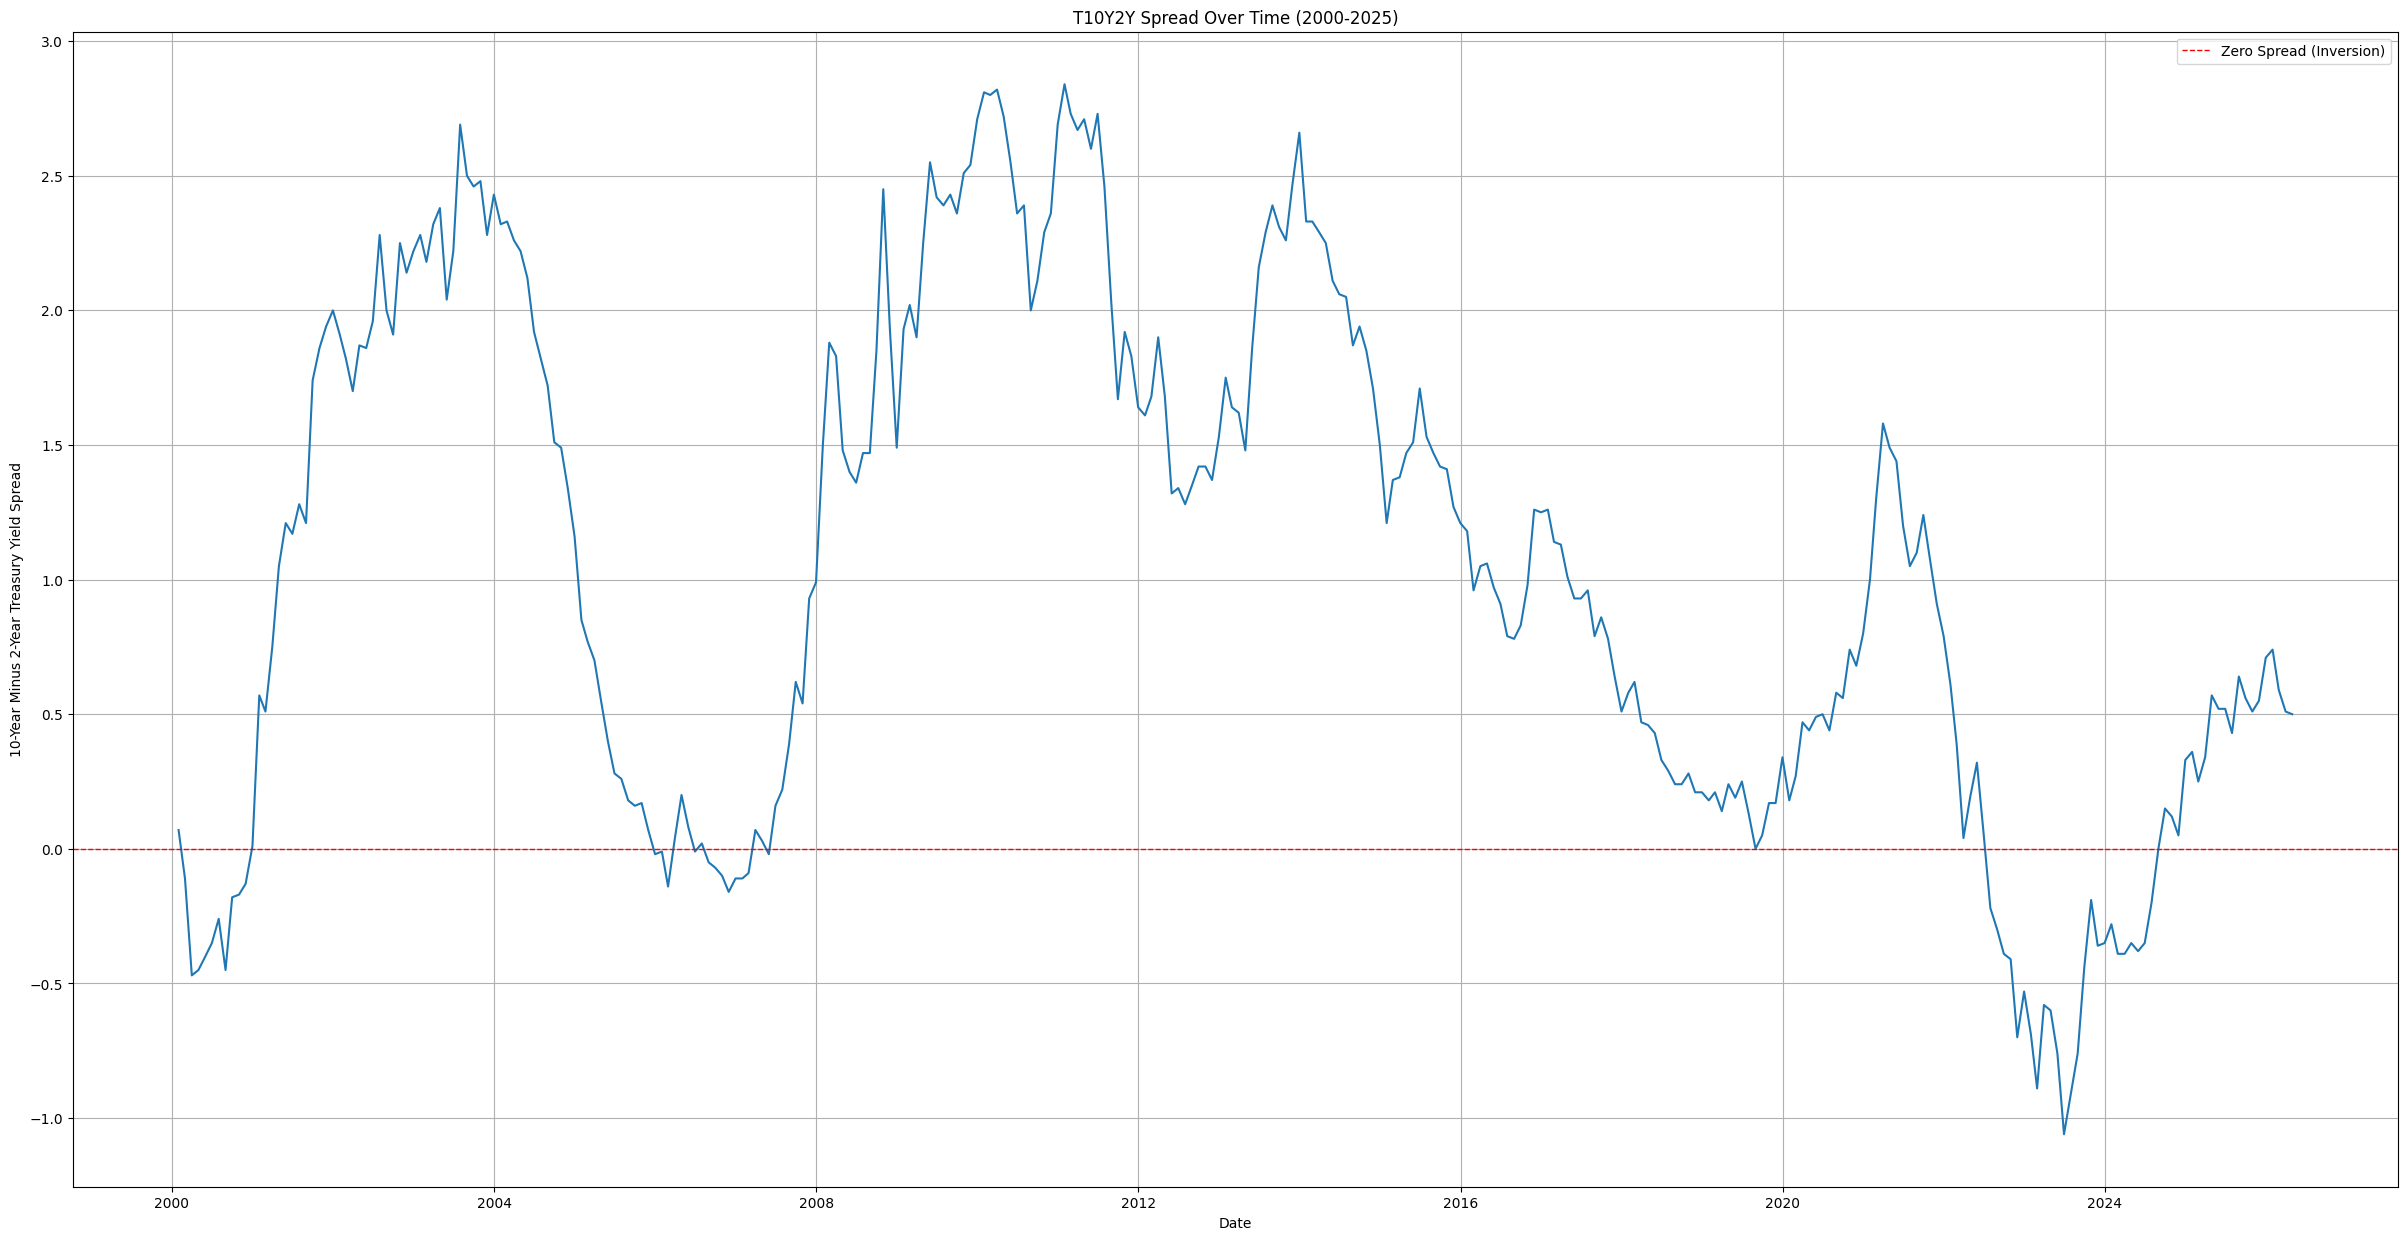

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(30, 15)) # Increased figure size
sns.lineplot(x=df_yields.index, y=df_yields['T10Y2Y'])
plt.axhline(0, color='red', linestyle='--', linewidth=1, label='Zero Spread (Inversion)')
plt.title('T10Y2Y Spread Over Time (2000-2025)')
plt.xlabel('Date')
plt.ylabel('10-Year Minus 2-Year Treasury Yield Spread')
plt.grid(True)
plt.legend()
plt.show()

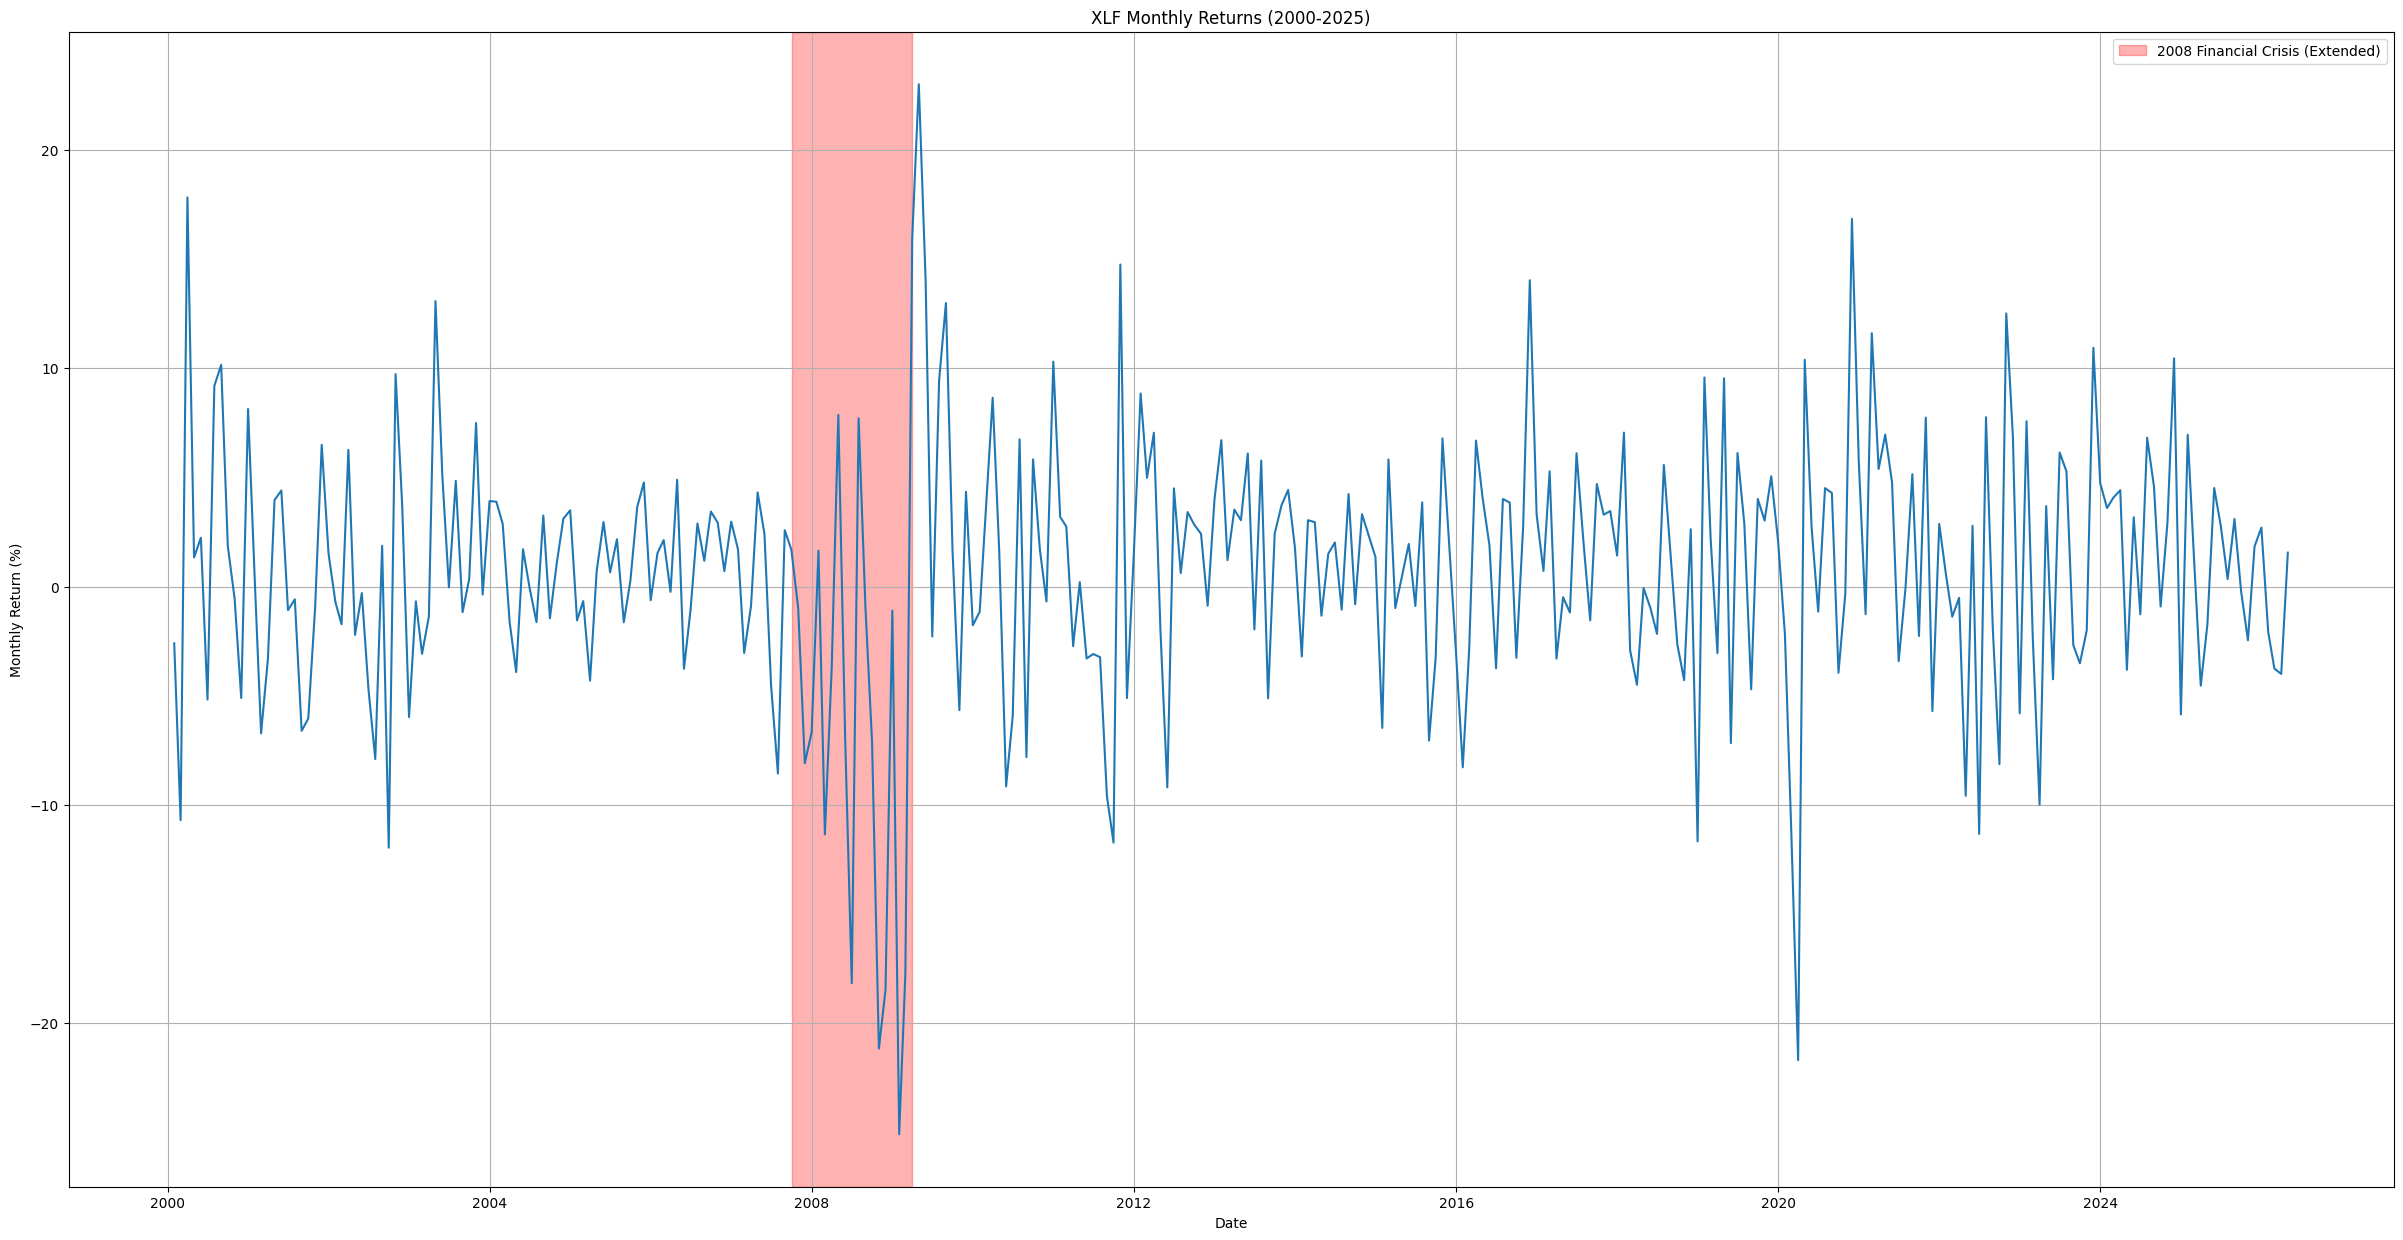

In [ ]:
plt.figure(figsize=(30,15)) # Increased figure size
sns.lineplot(x=df_sectors.index, y=df_sectors['XLF'] * 100) # Multiply by 100 for display
plt.axvspan(pd.to_datetime('2007-10-01'), pd.to_datetime('2009-03-31'), color='red', alpha=0.3, label='2008 Financial Crisis (Extended)')
plt.title('XLF Monthly Returns (2000-2025)')
plt.xlabel('Date')
plt.ylabel('Monthly Return (%)')
plt.grid(True)
plt.legend()
plt.show()

# 2. Feature Engineering & Regime Labels

In [ ]:
df_features = pd.DataFrame(index=df_yields.index)

# 1. Slope: DGS10 - DGS2
df_features['slope'] = df_yields['DGS10'] - df_yields['DGS2']

# 2. Level: mean of DGS2, DGS5, DGS10, DGS30
df_features['level'] = df_yields[['DGS2', 'DGS5', 'DGS10', 'DGS30']].mean(axis=1)

# 3. Curvature: 2 * DGS5 - DGS2 - DGS10
df_features['curvature'] = 2 * df_yields['DGS5'] - df_yields['DGS2'] - df_yields['DGS10']

# 4. 1-month differences
df_features['slope_chg_1m'] = df_features['slope'].diff(1)
df_features['level_chg_1m'] = df_features['level'].diff(1)
df_features['curvature_chg_1m'] = df_features['curvature'].diff(1)

# 5. 3-month differences
df_features['slope_chg_3m'] = df_features['slope'].diff(3)
df_features['level_chg_3m'] = df_features['level'].diff(3)

print("df_features head:")
print(df_features.head())
print("\ndf_features info:")
print(df_features.info())

df_features head:
            slope   level  ...  slope_chg_3m  level_chg_3m
2000-01-31   0.07  6.6225  ...           NaN           NaN
2000-02-29  -0.11  6.4275  ...           NaN           NaN
2000-03-31  -0.47  6.1725  ...           NaN           NaN
2000-04-30  -0.45  6.3600  ...         -0.52       -0.2625
2000-05-31  -0.40  6.3850  ...         -0.29       -0.0425

[5 rows x 8 columns]

df_features info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 316 entries, 2000-01-31 to 2026-04-30
Freq: ME
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   slope             316 non-null    float64
 1   level             316 non-null    float64
 2   curvature         316 non-null    float64
 3   slope_chg_1m      315 non-null    float64
 4   level_chg_1m      315 non-null    float64
 5   curvature_chg_1m  315 non-null    float64
 6   slope_chg_3m      313 non-null    float64
 7   level_chg_3m      313 non-n

In [ ]:
df_features.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 316 entries, 2000-01-31 to 2026-04-30
Freq: ME
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   slope             316 non-null    float64
 1   level             316 non-null    float64
 2   curvature         316 non-null    float64
 3   slope_chg_1m      315 non-null    float64
 4   level_chg_1m      315 non-null    float64
 5   curvature_chg_1m  315 non-null    float64
 6   slope_chg_3m      313 non-null    float64
 7   level_chg_3m      313 non-null    float64
dtypes: float64(8)
memory usage: 22.2 KB


In [ ]:
# Handle NaNs in df_features using forward fill
# NaNs are only at the beginning due to differencing, so ffill is appropriate.
df_features = df_features.ffill()

# After forward-filling, any remaining NaNs will be at the very beginning of the DataFrame
# where there was no previous value to fill from. We will drop these rows.
df_features = df_features.dropna(how='any')

# Verify that all NaNs have been handled
print("NaN counts in df_features after complete handling:")
print(df_features.isnull().sum())

NaN counts in df_features after complete handling:
slope               0
level               0
curvature           0
slope_chg_1m        0
level_chg_1m        0
curvature_chg_1m    0
slope_chg_3m        0
level_chg_3m        0
dtype: int64


In [ ]:
conditions = [
    (df_features['level_chg_3m'] > 0) & (df_features['slope_chg_3m'] > 0),
    (df_features['level_chg_3m'] > 0) & (df_features['slope_chg_3m'] < 0),
    (df_features['level_chg_3m'] < 0) & (df_features['slope_chg_3m'] > 0),
    (df_features['level_chg_3m'] < 0) & (df_features['slope_chg_3m'] < 0)
]

choices = ['Bear Steepening', 'Bear Flattening', 'Bull Steepening', 'Bull Flattening']

df_features['regime'] = np.select(conditions, choices, default='No Change/Other')

print("df_features with new 'regime' column head:")
display(df_features.head())
print("\nRegime distribution:")
print(df_features['regime'].value_counts())


df_features with new 'regime' column head:


,slope,level,curvature,slope_chg_1m,level_chg_1m,curvature_chg_1m,slope_chg_3m,level_chg_3m,regime
2000-04-30,-0.45,6.3600,0.21,0.02,0.1875,0.10,-0.52,-0.2625,Bull Flattening
2000-05-31,-0.40,6.3850,0.10,0.05,0.0250,-0.11,-0.29,-0.0425,Bull Flattening
2000-06-30,-0.35,6.1225,-0.05,0.05,-0.2625,-0.15,0.12,-0.0500,Bull Steepening
2000-07-31,-0.26,6.0725,-0.02,0.09,-0.0500,0.03,0.19,-0.2875,Bull Steepening
2000-08-31,-0.45,5.8900,0.05,-0.19,-0.1825,0.07,-0.05,-0.4950,Bull Flattening



Regime distribution:
regime
Bull Flattening    88
Bear Steepening    84
Bear Flattening    75
Bull Steepening    65
No Change/Other     1
Name: count, dtype: int64


In [ ]:
# Remove the 'No Change/Other' regime as it has only one observation
df_features = df_features[df_features['regime'] != 'No Change/Other']

print("df_features head after removing 'No Change/Other' regime:")
display(df_features.head())
print("\nRegime distribution after removal:")
print(df_features['regime'].value_counts())

df_features head after removing 'No Change/Other' regime:


,slope,level,curvature,slope_chg_1m,level_chg_1m,curvature_chg_1m,slope_chg_3m,level_chg_3m,regime
2000-04-30,-0.45,6.3600,0.21,0.02,0.1875,0.10,-0.52,-0.2625,Bull Flattening
2000-05-31,-0.40,6.3850,0.10,0.05,0.0250,-0.11,-0.29,-0.0425,Bull Flattening
2000-06-30,-0.35,6.1225,-0.05,0.05,-0.2625,-0.15,0.12,-0.0500,Bull Steepening
2000-07-31,-0.26,6.0725,-0.02,0.09,-0.0500,0.03,0.19,-0.2875,Bull Steepening
2000-08-31,-0.45,5.8900,0.05,-0.19,-0.1825,0.07,-0.05,-0.4950,Bull Flattening



Regime distribution after removal:
regime
Bull Flattening    88
Bear Steepening    84
Bear Flattening    75
Bull Steepening    65
Name: count, dtype: int64


In [ ]:
# Align df_sectors to the index of df_features before calculating new features
# This ensures both DataFrames cover the exact same time period after dropping initial NaNs in df_features
df_sectors_aligned = df_sectors.loc[df_features.index]

# Calculate XLF and XLK outperformance against SPY
# Outperformance is defined as (Sector Return - SPY Return) > 0
df_features['XLF_outperform'] = (df_sectors_aligned['XLF'] > df_sectors_aligned['SPY']).astype(int)
df_features['XLK_outperform'] = (df_sectors_aligned['XLK'] > df_sectors_aligned['SPY']).astype(int)

# Calculate forward 3-month XLF return
# This means the return from the current month to 3 months in the future.
# We need to shift the XLF returns up by 3 positions to get the future return.
# The last 3 months will result in NaN, which we'll handle later if needed for modeling.
df_features['XLF_forward_3m_return'] = df_sectors_aligned['XLF'].rolling(window=3).sum().shift(-3)

print("df_features head with new performance and forward return features:")
display(df_features.head())
print("\ndf_features tail (showing NaNs for forward returns):")
display(df_features.tail())

df_features head with new performance and forward return features:


/tmp/ipykernel_25018/3632173746.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_features['XLF_outperform'] = (df_sectors_aligned['XLF'] > df_sectors_aligned['SPY']).astype(int)
/tmp/ipykernel_25018/3632173746.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_features['XLK_outperform'] = (df_sectors_aligned['XLK'] > df_sectors_aligned['SPY']).astype(int)
/tmp/ipykernel_25018/3632173746.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .lo

,slope,level,curvature,slope_chg_1m,level_chg_1m,curvature_chg_1m,slope_chg_3m,level_chg_3m,regime,XLF_outperform,XLK_outperform,XLF_forward_3m_return
2000-04-30,-0.45,6.3600,0.21,0.02,0.1875,0.10,-0.52,-0.2625,Bull Flattening,1,0,0.062462
2000-05-31,-0.40,6.3850,0.10,0.05,0.0250,-0.11,-0.29,-0.0425,Bull Flattening,1,0,0.141712
2000-06-30,-0.35,6.1225,-0.05,0.05,-0.2625,-0.15,0.12,-0.0500,Bull Steepening,0,1,0.212150
2000-07-31,-0.26,6.0725,-0.02,0.09,-0.0500,0.03,0.19,-0.2875,Bull Steepening,1,0,0.114608
2000-08-31,-0.45,5.8900,0.05,-0.19,-0.1825,0.07,-0.05,-0.4950,Bull Flattening,1,1,-0.038050



df_features tail (showing NaNs for forward returns):


,slope,level,curvature,slope_chg_1m,level_chg_1m,curvature_chg_1m,slope_chg_3m,level_chg_3m,regime,XLF_outperform,XLK_outperform,XLF_forward_3m_return
2025-12-31,0.71,4.0550,-0.19,0.16,0.1175,0.12,0.15,-0.0025,Bull Steepening,1,1,-0.098540
2026-01-31,0.74,4.1100,-0.20,0.03,0.0550,-0.01,0.23,0.0875,Bear Steepening,0,0,-0.062143
2026-02-28,0.59,3.8750,-0.33,-0.15,-0.2350,-0.13,0.04,-0.0625,Bull Steepening,0,0,NaN
2026-03-31,0.51,4.2225,-0.25,-0.08,0.3475,0.08,-0.20,0.1675,Bear Flattening,1,1,NaN
2026-04-30,0.51,4.2725,-0.21,0.00,0.0500,0.04,-0.23,0.1625,Bear Flattening,0,1,NaN


In [ ]:
print("XLF Outperformance Distribution:")
print(df_features['XLF_outperform'].value_counts())

print("\nXLK Outperformance Distribution:")
print(df_features['XLK_outperform'].value_counts())

XLF Outperformance Distribution:
XLF_outperform
0    161
1    151
Name: count, dtype: int64

XLK Outperformance Distribution:
XLK_outperform
1    160
0    152
Name: count, dtype: int64


/tmp/ipykernel_25018/2562363145.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='regime', y='XLF_forward_3m_return', data=df_plot, palette='viridis')


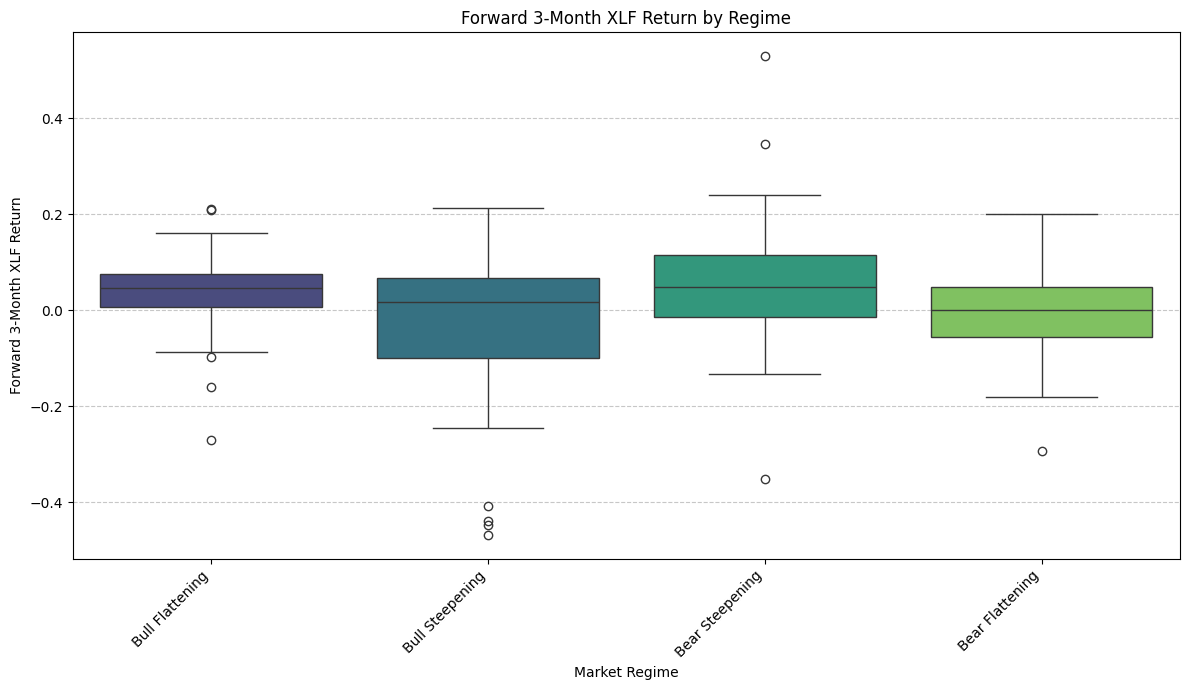

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Drop NaNs for the box plot, as forward returns for the last 3 months are NaN
# We temporarily create a copy for plotting to avoid modifying the original df_features yet
df_plot = df_features.dropna(subset=['XLF_forward_3m_return']).copy()

plt.figure(figsize=(12, 7))
sns.boxplot(x='regime', y='XLF_forward_3m_return', data=df_plot, palette='viridis')
plt.title('Forward 3-Month XLF Return by Regime')
plt.xlabel('Market Regime')
plt.ylabel('Forward 3-Month XLF Return')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()